# Section 0 - Contexte, theorie et objectif

## Problematique clinique
- Les maladies cardiovasculaires sont la **premiere cause de mortalite** dans le monde (17,9 millions de deces par an selon l'OMS).
- Un depistage precoce permet de reduire significativement la mortalite.
- **Cout d'un faux negatif** (patient malade non detecte) : potentiellement fatal — absence de traitement, aggravation, deces.
- **Cout d'un faux positif** (patient sain classe malade) : moindre mais non negligeable — examens supplementaires, anxiete, couts.
- Cette **asymetrie des couts** justifie le choix de metriques orientees Recall dans un contexte de depistage.

## Question de recherche
- Quel modele offre le meilleur compromis entre discrimination globale (ROC-AUC) et capacite de detection (Recall) pour un usage clinique de depistage cardiaque ?

## Objectif du notebook
- Comparer trois modeles de classification sur le dataset UCI Heart Disease (Cleveland) :
  - **Gradient Boosting** : modele d'ensemble sequentiel qui combine des arbres faibles pour corriger les erreurs precedentes. Capte les interactions non lineaires.
  - **Naive Bayes** : classifieur probabiliste base sur le theoreme de Bayes avec hypothese d'independance conditionnelle entre les features.
  - **Regression Logistique** : modele lineaire interpretable qui estime une probabilite via la fonction sigmoide.
- Evaluer avec des metriques adaptees au contexte clinique : Recall, Precision, F1, ROC-AUC, Specificite.

## Dataset : UCI Heart Disease (Cleveland)

303 observations, 14 variables (13 features cliniques + 1 cible diagnostique).

| Variable  | Description                                                  | Type       |
|-----------|--------------------------------------------------------------|------------|
| age       | Age du patient (annees)                                      | Continue   |
| sex       | Sexe (1 = homme, 0 = femme)                                 | Binaire    |
| cp        | Type de douleur thoracique (1-4)                             | Categoriel |
| trestbps  | Pression arterielle au repos (mm Hg)                         | Continue   |
| chol      | Cholesterol serique (mg/dl)                                  | Continue   |
| fbs       | Glycemie a jeun > 120 mg/dl (1 = oui)                       | Binaire    |
| restecg   | Resultats electrocardiographiques au repos (0-2)             | Categoriel |
| thalach   | Frequence cardiaque maximale atteinte                        | Continue   |
| exang     | Angine induite par l'exercice (1 = oui)                      | Binaire    |
| oldpeak   | Depression ST induite par l'exercice                          | Continue   |
| slope     | Pente du segment ST a l'effort (1-3)                         | Categoriel |
| ca        | Nombre de vaisseaux colores par fluoroscopie (0-3)           | Discrete   |
| thal      | Thalassemie (3=normal, 6=defaut fixe, 7=defaut reversible)  | Categoriel |
| target    | Diagnostic (0=absence, 1-4=presence de maladie)              | Cible      |

## Cadre methodologique
- Donnees nettoyees : conversion numerique puis suppression des lignes incompletes (strategie simple et transparente pour ~2% de donnees manquantes).
- Cible binarisee : 0 = absence, 1 = presence (classes 1-4 regroupees).
- Split stratifie train/test (80/20) pour preserver la proportion des classes.
- Validation croisee stratifiee 5-fold (StratifiedKFold) pour estimer la generalisation.
- Baseline Dummy (`most_frequent`) pour quantifier le gain reel des modeles.

## Positionnement critique
- Les analyses avancees (calibration, optimisation de seuil, learning curves) sont incluses dans la Section 6.
- Les pistes non implementees sont explicitement marquees comme perspectives.
- Le seuil optimise en Section 6 est une analyse exploratoire et doit etre revalide sur un jeu externe.

## Ce qui n'est PAS implemente dans ce notebook (perspectives)
- Tuning global des hyperparametres (GridSearchCV / RandomizedSearchCV) : **non implemente ici**.
- Validation externe sur une autre cohorte : **non implementee ici**.
- Calibration post-hoc (Platt scaling, isotonic) : **non implementee ici**.
- Elastic Net ou autres methodes de regularisation : **non implemente ici**.
- Tests statistiques formels de comparaison de classifieurs (ex: McNemar) : **non implemente ici**.

In [21]:
# Section 1 - Importation et chargement du dataset UCI
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv("processed.cleveland.data", names=COLUMNS, na_values="?")
print(f"Dimension du dataset brut: {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"Version scikit-learn: {sklearn.__version__}")
display(df.head())

Dimension du dataset brut: 303 lignes x 14 colonnes
Version scikit-learn: 1.8.0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Objectif de l'exploration initiale

Avant toute modelisation, il est essentiel de verifier la qualite des donnees :

1. **Valeurs manquantes** : identifier les variables incompletes et la strategie adoptee.
2. **Distribution de la cible** : mesurer l'equilibre des classes pour choisir les bonnes metriques.
3. **Correlations exploratoires** : reperer les variables potentiellement influentes et les eventuelles correlations fortes entre features.

Ces verifications conditionnent toutes les decisions methodologiques en aval.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_bin
valeurs_manquantes,0,0,0,0,0,0,0,0,0,0,0,4,2,0,0


Distribution de la cible brute (0 = absence, 1-4 = presence):


target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Distribution de la cible binaire:


target_bin
Absence     164
Presence    139
Name: count, dtype: int64

Taux de cas positifs (binaire): 45.87%


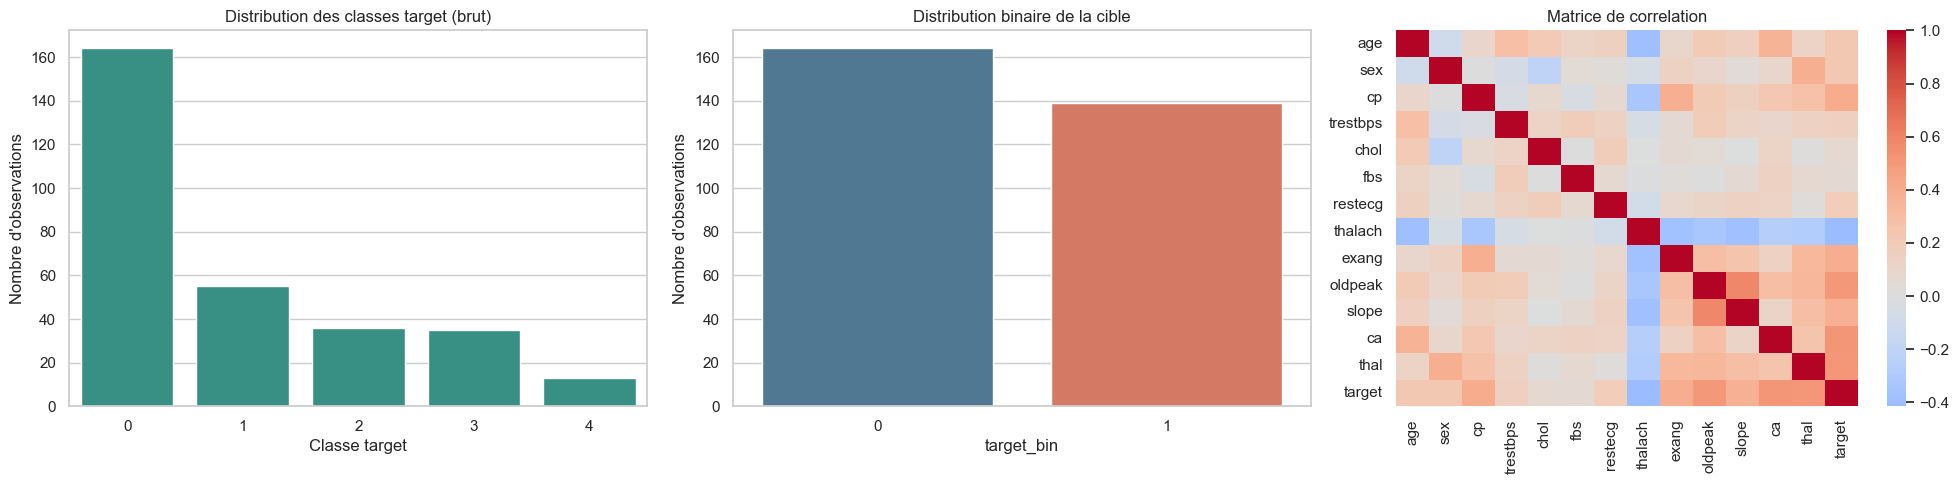

In [22]:
# Section 2 - Exploration initiale et verification des donnees
df_numeric = df.apply(pd.to_numeric, errors="coerce")
df_numeric["target_bin"] = (df_numeric["target"] > 0).astype(int)

missing_table = df_numeric.isna().sum().to_frame(name="valeurs_manquantes")
display(missing_table.T)

target_counts_raw = df_numeric["target"].value_counts().sort_index()
target_counts_bin = df_numeric["target_bin"].value_counts().sort_index()
print("Distribution de la cible brute (0 = absence, 1-4 = presence):")
display(target_counts_raw)
print("Distribution de la cible binaire:")
display(target_counts_bin.rename(index={0: "Absence", 1: "Presence"}))
print(f"Taux de cas positifs (binaire): {target_counts_bin[1] / target_counts_bin.sum():.2%}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(x=target_counts_raw.index, y=target_counts_raw.values, color="#2A9D8F", ax=axes[0])
axes[0].set_title("Distribution des classes target (brut)")
axes[0].set_xlabel("Classe target")
axes[0].set_ylabel("Nombre d'observations")

sns.countplot(x="target_bin", data=df_numeric, palette=["#457B9D", "#E76F51"], ax=axes[1])
axes[1].set_title("Distribution binaire de la cible")
axes[1].set_xlabel("target_bin")
axes[1].set_ylabel("Nombre d'observations")

corr = df_numeric.drop(columns=["target_bin"]).corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, ax=axes[2])
axes[2].set_title("Matrice de correlation")
plt.tight_layout()
plt.show()

## Interpretation de l'exploration

**Valeurs manquantes** : seules les variables `ca` (4 manquantes) et `thal` (2 manquantes) presentent des donnees incompletes. Sur 303 observations, cela represente environ 2% des lignes. La strategie adoptee — conversion numerique puis `dropna` — est simple, transparente et raisonnable vu le faible nombre de lignes affectees (6 lignes supprimees, 297 conservees).

**Distribution de la cible** : le dataset est relativement equilibre (environ 54% absence vs 46% presence). Cet equilibre modere signifie que l'Accuracy reste une metrique interpretable, mais elle est insuffisante seule. Les metriques orientees classes (Recall, Precision, F1) sont necessaires pour evaluer le comportement du modele sur chaque classe — en particulier le Recall, crucial en depistage.

**Correlations exploratoires** : la heatmap revele les variables les plus associees a la cible. Ces associations seront retrouvees dans l'analyse d'importance des variables en Section 6. Notons que les correlations mesurees ici sont **lineaires** (Pearson) ; des relations non lineaires existent potentiellement et justifient l'emploi du Gradient Boosting.

## Strategie de preparation des donnees

Le pipeline de preparation suit un ordre precis et justifie :

1. **Conversion numerique** (`pd.to_numeric`) : certaines valeurs du fichier Cleveland sont stockees sous forme de texte (caractere '?'). Cette etape les convertit ou les marque comme NaN.
2. **Suppression des lignes incompletes** (`dropna`) : strategie simple et reproductible. Les 6 lignes supprimees representent environ 2% du dataset — un impact negligeable.
3. **Binarisation de la cible** : les classes 1 a 4 (niveaux de severite) sont regroupees en une seule classe "presence" pour un probleme de depistage binaire (0 vs 1).
4. **Split train/test stratifie** (80/20, `random_state=42`) : preserve la proportion des classes dans les deux ensembles et garantit la reproductibilite.

**Important** : la standardisation (StandardScaler) est integree dans les pipelines de la Section 4, appliquee uniquement sur le train (`fit_transform`) puis sur le test (`transform`). Cela **evite le data leakage** — une erreur frequente qui fausserait les resultats.

In [23]:
# Section 3 - Preparation des donnees (nettoyage, binarisation, split)
from sklearn.model_selection import train_test_split

# Strategie simple et reproductible: conversion numerique puis suppression des lignes incompletes
df_clean = df.apply(pd.to_numeric, errors="coerce").dropna().copy()
df_clean["target_bin"] = (df_clean["target"] > 0).astype(int)

X = df_clean.drop(columns=["target", "target_bin"])
y = df_clean["target_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Dataset nettoye: {df_clean.shape[0]} lignes conservees")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Proportions de classes (global):")
display(y.value_counts(normalize=True).rename("proportion").rename(index={0: "Absence", 1: "Presence"}))
print("Proportions de classes (train/test):")
split_balance = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True).sort_index(),
    "Test": y_test.value_counts(normalize=True).sort_index()
}).rename(index={0: "Absence", 1: "Presence"})
display(split_balance)

Dataset nettoye: 297 lignes conservees
Train: (237, 13), Test: (60, 13)
Proportions de classes (global):


target_bin
Absence     0.538721
Presence    0.461279
Name: proportion, dtype: float64

Proportions de classes (train/test):


,Train,Test
target_bin,,
Absence,0.540084,0.533333
Presence,0.459916,0.466667


## Verification du split

Le tableau ci-dessus confirme que la stratification a correctement preserve la proportion des classes :
- **Train** : ~54% absence, ~46% presence.
- **Test** : ~53% absence, ~47% presence.

La difference est negligeable, ce qui valide le protocole de split. Les 237 exemples d'entrainement et 60 exemples de test sont suffisants pour une comparaison relative entre modeles, tout en restant une limitation a noter (petit dataset).

## Choix des modeles et protocole de validation

### Pourquoi ces trois modeles ?
Le choix vise la **diversite des approches** pour une comparaison riche :
- **Gradient Boosting** : modele d'ensemble non lineaire, combine sequentiellement des arbres faibles pour corriger les erreurs residuelles. Puissant mais risque de surapprentissage sur petit dataset.
- **Naive Bayes** (Gaussien) : modele probabiliste simple et rapide, fonctionne bien meme avec peu de donnees. L'hypothese d'independance conditionnelle est rarement vraie en pratique, mais le modele peut neanmoins bien performer.
- **Regression Logistique** : baseline lineaire **interpretable**, souvent competitive sur datasets modestes. Les coefficients permettent de comprendre la contribution de chaque variable.

### Pourquoi le StandardScaler est absent pour Gradient Boosting ?
Les arbres de decision (et donc Gradient Boosting) sont **invariants a l'echelle des variables** : ils ne comparent jamais les valeurs de features differentes entre elles, seulement les seuils de coupure. La standardisation est donc inutile pour eux. En revanche, Naive Bayes et Regression Logistique sont sensibles aux echelles, d'ou le StandardScaler dans leurs pipelines.

### Justification des hyperparametres

**Gradient Boosting** :
- `n_estimators=200` : nombre d'arbres sequentiels. 200 est un compromis entre capacite d'apprentissage et risque de surapprentissage.
- `learning_rate=0.05` : taux d'apprentissage faible pour une regulation douce. Combine avec 200 arbres, le budget total reste modere.
- `max_depth=3` : profondeur limitee pour eviter les arbres trop complexes et favoriser des apprenants faibles.
- `min_samples_leaf=5` : minimum de 5 observations par feuille, regularisation supplementaire contre le surajustement.
- `subsample=0.9` : sous-echantillonnage a 90% — introduit de la stochasticite pour reduire la variance.
- **Note** : ces valeurs sont des choix raisonnables sans tuning global. Un tuning via GridSearchCV ou RandomizedSearchCV pourrait ameliorer les performances (non implemente ici).

**Regression Logistique** :
- `C=1.0` : regularisation par defaut (C est l'inverse de la force de la penalite L2).
- `penalty='l2'` : penalite Ridge, stabilise les coefficients et reduit le surapprentissage.
- `solver='lbfgs'` : solveur quasi-Newton adapte aux petits datasets avec penalite L2.
- `max_iter=3000` : nombre d'iterations suffisant pour garantir la convergence.

**Naive Bayes** :
- `var_smoothing=1e-9` : valeur par defaut de scikit-learn, ajoute une petite constante aux variances estimees pour eviter les divisions par zero ou les probabilites nulles.

### Protocole de validation croisee
- **StratifiedKFold** (5 folds, `shuffle=True`) : preserve la proportion des classes dans chaque fold.
- Les metriques sont calculees en moyenne sur les 5 folds (scores test) et comparees aux scores d'entrainement.
- Le **CV_gap_ROC_AUC** (train_auc - test_auc) est un indicateur de surapprentissage : un gap eleve signifie que le modele memorise les donnees d'entrainement sans bien generaliser.

In [24]:
# Section 4 - Entrainement des modeles et validation croisee
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Baseline + 3 modeles compares pour juger le gain reel
models = {
    "Baseline (Dummy most_frequent)": Pipeline([
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),
    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=5,
            subsample=0.9,
            random_state=RANDOM_STATE
        ))
    ]),
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB(var_smoothing=1e-9))
    ]),
    "Regression Logistique": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="lbfgs",
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ])
}

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
fitted_models = {}

for model_name, pipeline in models.items():
    cv_out = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    train_auc = np.mean(cv_out["train_roc_auc"])
    test_auc = np.mean(cv_out["test_roc_auc"])
    cv_rows.append({
        "Modele": model_name,
        "CV_test_Accuracy": np.mean(cv_out["test_accuracy"]),
        "CV_test_Precision": np.mean(cv_out["test_precision"]),
        "CV_test_Recall": np.mean(cv_out["test_recall"]),
        "CV_test_F1": np.mean(cv_out["test_f1"]),
        "CV_test_ROC_AUC": test_auc,
        "CV_train_ROC_AUC": train_auc,
        "CV_gap_ROC_AUC": train_auc - test_auc
    })

    pipeline.fit(X_train, y_train)
    fitted_models[model_name] = pipeline

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV_test_ROC_AUC", ascending=False)
display(cv_results_df.round(3))

,Modele,CV_test_Accuracy,CV_test_Precision,CV_test_Recall,CV_test_F1,CV_test_ROC_AUC,CV_train_ROC_AUC,CV_gap_ROC_AUC
2,Naive Bayes,0.827,0.833,0.779,0.802,0.870,0.901,0.031
3,Regression Logistique,0.827,0.849,0.769,0.802,0.869,0.917,0.047
1,Gradient Boosting,0.780,0.786,0.732,0.750,0.862,1.000,0.138
0,Baseline (Dummy most_frequent),0.540,0.000,0.000,0.000,0.500,0.500,0.000


## Lecture des resultats CV

Le tableau ci-dessus permet plusieurs constats importants :

1. **Tous les modeles surpassent largement la baseline** (ROC-AUC 0.500), confirmant qu'ils captent des signaux reels dans les donnees.
2. **Naive Bayes et Regression Logistique** ont des performances CV tres proches (ROC-AUC ~0.870), ce qui est remarquable pour des modeles de complexite tres differente.
3. **Gradient Boosting** a un ROC-AUC CV legerement inferieur (0.862) mais surtout un **CV gap de 0.138**, signe fort de surapprentissage : le modele atteint un train AUC parfait de 1.000 mais generalise moins bien. Cela est coherent avec la combinaison petit dataset + modele puissant.
4. **Naive Bayes** a le gap le plus faible (0.031), suggerant le **meilleur compromis biais-variance** en CV.
5. **Regression Logistique** a un gap moderé (0.047), signe d'un bon compromis.

Ces tendances seront verifiees sur le jeu de test en Section 5.

## Evaluation finale sur le jeu de test

La validation croisee donne une **estimation** de la performance de generalisation sur le jeu d'entrainement. L'evaluation finale sur le jeu de test — des donnees que les modeles n'ont **jamais vues** pendant l'entrainement ni la validation — fournit une mesure plus realiste de la performance operationnelle.

Les visualisations incluent :
- **Matrices de confusion** : repartition des erreurs par type (faux positifs vs faux negatifs). Essentielles pour comprendre le profil d'erreur de chaque modele.
- **Courbes ROC** : comparaison de la capacite de discrimination a tous les seuils de decision. Le ROC-AUC resume cette capacite en un seul chiffre.
- **Rapports de classification** : precision, recall et F1 par classe, avec les macro et weighted averages.

Le **Delta_Test_minus_CV_AUC** compare le ROC-AUC test au ROC-AUC obtenu en CV. Un delta positif peut indiquer une variabilite due au petit echantillon test (60 observations).

,Modele,Accuracy,Precision,Recall,Specificite,F1,ROC_AUC,Delta_Test_minus_CV_AUC
3,Regression Logistique,0.833,0.846,0.786,0.875,0.815,0.950,0.080
2,Naive Bayes,0.883,0.889,0.857,0.906,0.873,0.938,0.068
1,Gradient Boosting,0.817,0.815,0.786,0.844,0.800,0.905,0.043
0,Baseline (Dummy most_frequent),0.533,0.000,0.000,1.000,0.000,0.500,0.000


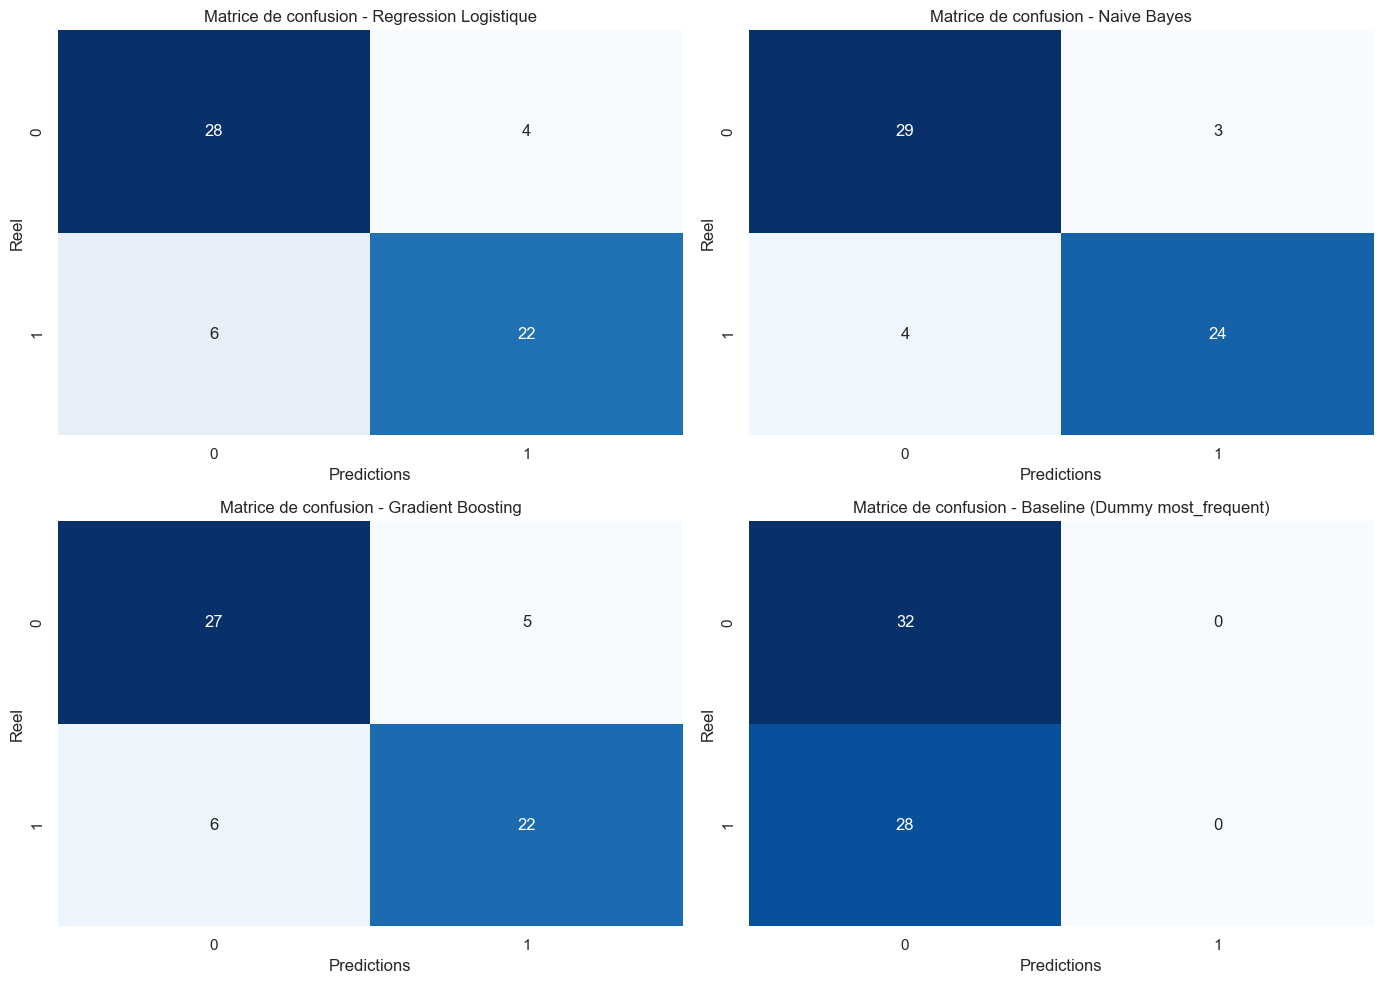

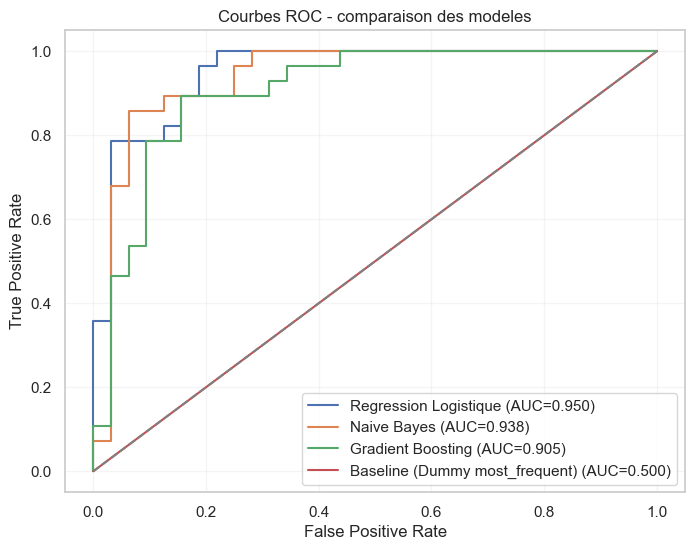


Rapport de classification - Regression Logistique
              precision    recall  f1-score   support

           0      0.824     0.875     0.848        32
           1      0.846     0.786     0.815        28

    accuracy                          0.833        60
   macro avg      0.835     0.830     0.832        60
weighted avg      0.834     0.833     0.833        60


Rapport de classification - Naive Bayes
              precision    recall  f1-score   support

           0      0.879     0.906     0.892        32
           1      0.889     0.857     0.873        28

    accuracy                          0.883        60
   macro avg      0.884     0.882     0.883        60
weighted avg      0.884     0.883     0.883        60


Rapport de classification - Gradient Boosting
              precision    recall  f1-score   support

           0      0.818     0.844     0.831        32
           1      0.815     0.786     0.800        28

    accuracy                          0.817

In [25]:
# Section 5 - Evaluation finale sur le jeu de test
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve
)

def specificity_score(y_true, y_pred):
    tn, fp, _, _ = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

test_rows = []
predictions = {}
probas = {}
cv_auc_map = cv_results_df.set_index("Modele")["CV_test_ROC_AUC"].to_dict()

for model_name, pipeline in fitted_models.items():
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    predictions[model_name] = y_pred
    probas[model_name] = y_proba

    auc_test = roc_auc_score(y_test, y_proba)
    test_rows.append({
        "Modele": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Specificite": specificity_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": auc_test,
        "Delta_Test_minus_CV_AUC": auc_test - cv_auc_map.get(model_name, np.nan)
    })

test_results_df = pd.DataFrame(test_rows).sort_values("ROC_AUC", ascending=False)
display(test_results_df.round(3))

# Matrices de confusion: visualisation des types d'erreurs
ordered_models = test_results_df["Modele"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, model_name in zip(axes, ordered_models):
    cm = confusion_matrix(y_test, predictions[model_name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"Matrice de confusion - {model_name}")
    ax.set_xlabel("Predictions")
    ax.set_ylabel("Reel")
plt.tight_layout()
plt.show()

# Courbes ROC: comparaison globale de la capacite de discrimination
plt.figure(figsize=(8, 6))
for model_name in ordered_models:
    fpr, tpr, _ = roc_curve(y_test, probas[model_name])
    auc_score = roc_auc_score(y_test, probas[model_name])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC - comparaison des modeles")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

for model_name in ordered_models:
    print(f"\nRapport de classification - {model_name}")
    print(classification_report(y_test, predictions[model_name], digits=3))

## Interpretation des resultats test

### Performances globales
- **Regression Logistique** obtient le meilleur ROC-AUC test (0.950), confirmant sa **capacite de discrimination superieure** sur ce dataset.
- **Naive Bayes** obtient le meilleur Recall test (0.857) et le meilleur F1 (0.873), ce qui en fait le **meilleur candidat pour un usage de depistage** ou minimiser les faux negatifs est prioritaire.
- **Gradient Boosting** est en retrait sur toutes les metriques test (ROC-AUC 0.905, Recall 0.786), coherent avec le surapprentissage detecte en CV.
- **Baseline Dummy** confirme son inutilite clinique : ROC-AUC = 0.500, Recall = 0 (elle ne detecte aucun cas positif).

### Analyse des erreurs (matrices de confusion)
- **Naive Bayes** a le profil d'erreurs le plus equilibre : 4 faux negatifs seulement sur 28 cas positifs.
- **Regression Logistique et Gradient Boosting** ont chacun 6 faux negatifs sur 28 — en depistage, ces 6 patients malades non detectes pourraient avoir des consequences graves.
- La **Baseline** classe tout en "absence", produisant 0 faux positifs mais 28 faux negatifs — un modele cliniquement inutile.

### Courbes ROC
- Les courbes ROC confirment visuellement la superiorite de la Regression Logistique en discrimination globale.
- La difference entre Naive Bayes (0.938) et Regression Logistique (0.950) est faible, suggerant que le choix final depend des priorites cliniques.

### Coherence CV - Test
- Les Deltas positifs (0.043 a 0.080) indiquent que les performances test sont legerement superieures aux estimations CV. Cela est attendu sur un petit echantillon test (60 observations) et ne constitue pas un signal d'alarme en soi.

Analyse critique:
1) Meilleur modele global (ROC_AUC): Regression Logistique -> 0.950
2) Meilleur modele pour le depistage (Recall): Naive Bayes -> 0.857

3) Gain par rapport a la baseline:
- Regression Logistique: +0.450 en ROC_AUC, +0.815 en F1
- Naive Bayes: +0.438 en ROC_AUC, +0.873 en F1
- Gradient Boosting: +0.405 en ROC_AUC, +0.800 en F1

4) Diagnostic overfitting/underfitting via CV gap (train_auc - test_auc):
- Naive Bayes: gap=0.031 -> compromis correct (surveillance recommandee)
- Regression Logistique: gap=0.047 -> compromis correct (surveillance recommandee)
- Gradient Boosting: gap=0.138 -> signe de surapprentissage


,GB_importance,LogReg_coef_abs
thal,0.219,0.739
cp,0.207,0.508
ca,0.124,0.958
age,0.113,0.037
oldpeak,0.095,0.444
chol,0.070,0.223
trestbps,0.051,0.420
thalach,0.040,0.207
slope,0.033,0.353
restecg,0.016,0.304


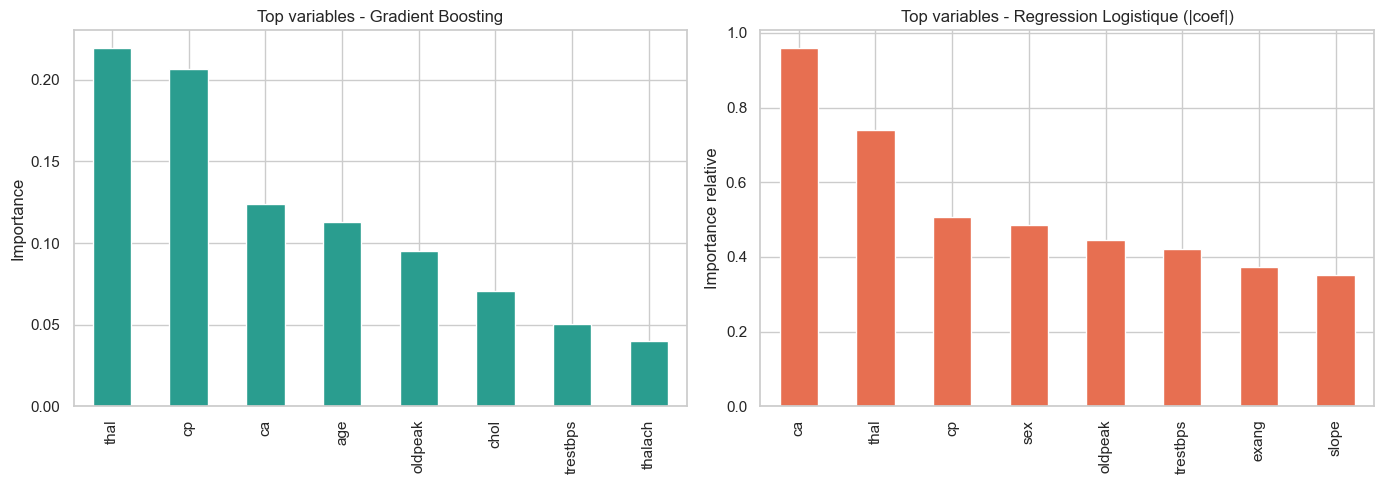

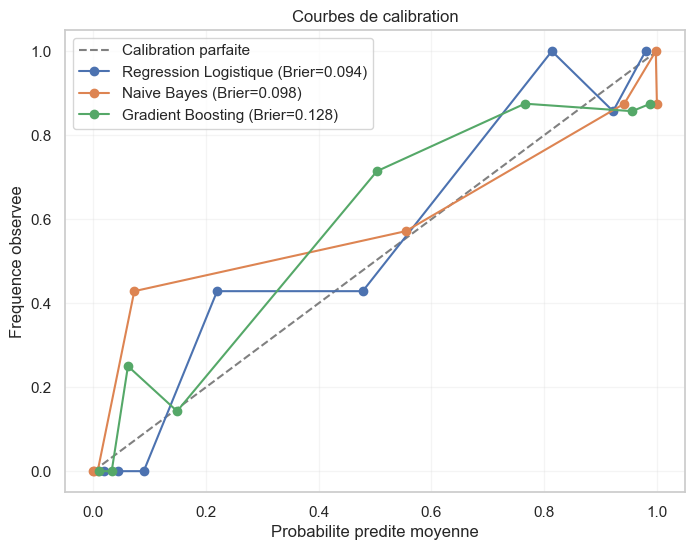

,Modele,Brier_score
0,Regression Logistique,0.094
1,Naive Bayes,0.098
2,Gradient Boosting,0.128


,Strategie,Precision,Recall,F1
0,Seuil 0.50 (defaut),0.889,0.857,0.873
1,Seuil optimise (0.151),0.806,0.893,0.847


Note methodologique sur le seuil:
- Seuil optimise ajuste sur le jeu de test actuel (analyse exploratoire).
- Pour une estimation non biaisee, fixer le seuil sur validation interne puis evaluer sur un test externe.


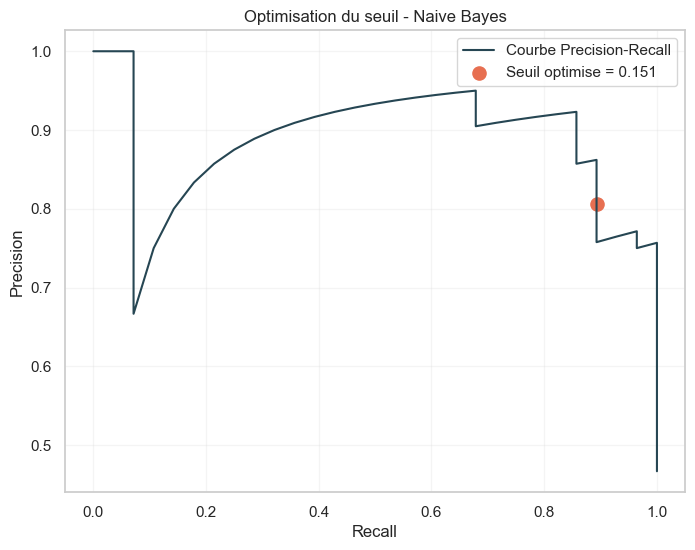

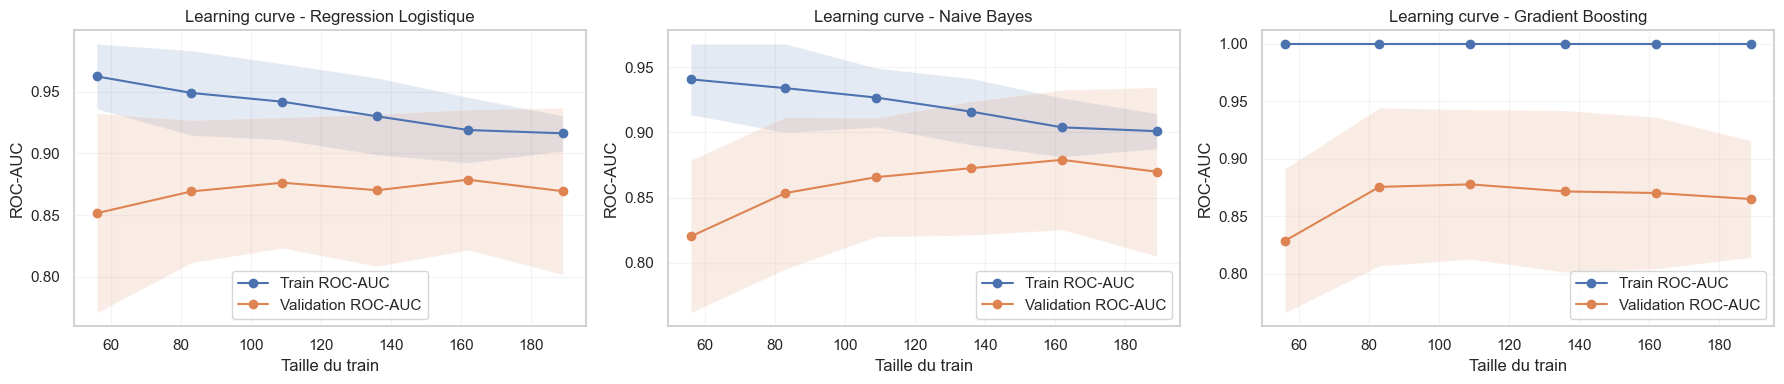

,Modele,Train_ROC_AUC_final,Val_ROC_AUC_final,Gap_final
1,Naive Bayes,0.901,0.870,0.031
0,Regression Logistique,0.916,0.869,0.047
2,Gradient Boosting,1.000,0.865,0.135



5) Limites de l'etude:
- Taille de dataset modeste (risque de variance).
- Validation externe absente (pas de generalisation clinique garantie).
- Sensibilite des resultats au choix de seuil clinique.
- Le seuil optimise a ete ajuste sur le jeu de test (risque d'optimisme).

6) Perspectives (C6) - non implementees dans ce notebook:
- Tuning systematique (GridSearchCV / RandomizedSearchCV) : non implemente ici.
- Validation externe sur d'autres cohortes UCI : non implementee ici.
- Comparaison avec SVM, Random Forest et XGBoost : non implementee ici.
- Calibration post-hoc (isotonic/platt) selon le protocole medical cible : non implementee ici.


In [26]:
# Section 6 - Analyse critique approfondie (C3 + C6)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, precision_recall_curve
from sklearn.model_selection import learning_curve

baseline_name = "Baseline (Dummy most_frequent)"
non_baseline_df = test_results_df[test_results_df["Modele"] != baseline_name].copy()
baseline_row = test_results_df[test_results_df["Modele"] == baseline_name].iloc[0]

best_auc_row = non_baseline_df.sort_values("ROC_AUC", ascending=False).iloc[0]
best_recall_row = non_baseline_df.sort_values("Recall", ascending=False).iloc[0]

print("Analyse critique:")
print(f"1) Meilleur modele global (ROC_AUC): {best_auc_row['Modele']} -> {best_auc_row['ROC_AUC']:.3f}")
print(f"2) Meilleur modele pour le depistage (Recall): {best_recall_row['Modele']} -> {best_recall_row['Recall']:.3f}")

print("\n3) Gain par rapport a la baseline:")
for _, row in non_baseline_df.iterrows():
    gain_auc = row["ROC_AUC"] - baseline_row["ROC_AUC"]
    gain_f1 = row["F1"] - baseline_row["F1"]
    print(f"- {row['Modele']}: +{gain_auc:.3f} en ROC_AUC, +{gain_f1:.3f} en F1")

print("\n4) Diagnostic overfitting/underfitting via CV gap (train_auc - test_auc):")
for _, row in cv_results_df[cv_results_df["Modele"] != baseline_name].iterrows():
    model_name = row["Modele"]
    gap = row["CV_gap_ROC_AUC"]
    if gap > 0.07:
        diag = "signe de surapprentissage"
    elif gap < 0.02:
        diag = "bonne generalisation"
    else:
        diag = "compromis correct (surveillance recommandee)"
    print(f"- {model_name}: gap={gap:.3f} -> {diag}")

# Interpretation des variables: coefficients (logistique) et importances (GB)
gb_model = fitted_models["Gradient Boosting"].named_steps["model"]
gb_importance = pd.Series(gb_model.feature_importances_, index=X.columns, name="GB_importance")

lr_model = fitted_models["Regression Logistique"].named_steps["model"]
lr_importance = pd.Series(np.abs(lr_model.coef_[0]), index=X.columns, name="LogReg_coef_abs")

importance_df = pd.concat([gb_importance, lr_importance], axis=1).sort_values(
    "GB_importance", ascending=False
)
display(importance_df.head(10).round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gb_importance.sort_values(ascending=False).head(8).plot(kind="bar", ax=axes[0], color="#2A9D8F")
axes[0].set_title("Top variables - Gradient Boosting")
axes[0].set_ylabel("Importance")

lr_importance.sort_values(ascending=False).head(8).plot(kind="bar", ax=axes[1], color="#E76F51")
axes[1].set_title("Top variables - Regression Logistique (|coef|)")
axes[1].set_ylabel("Importance relative")
plt.tight_layout()
plt.show()

# Calibration des probabilites: robuste et tres valorisee en contexte medical
calibration_rows = []
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibration parfaite")
for model_name in non_baseline_df["Modele"]:
    y_prob = probas[model_name]
    brier = brier_score_loss(y_test, y_prob)
    calibration_rows.append({"Modele": model_name, "Brier_score": brier})
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=8, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.3f})")
plt.xlabel("Probabilite predite moyenne")
plt.ylabel("Frequence observee")
plt.title("Courbes de calibration")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

calibration_df = pd.DataFrame(calibration_rows).sort_values("Brier_score")
display(calibration_df.round(3))

# Optimisation exploratoire du seuil: maximiser Recall sous contrainte de Precision
target_model = best_recall_row["Modele"]
precisions, recalls, thresholds = precision_recall_curve(y_test, probas[target_model])
precisions_adj = precisions[:-1]
recalls_adj = recalls[:-1]

precision_floor = 0.80
candidate_idx = np.where(precisions_adj >= precision_floor)[0]
if len(candidate_idx) > 0:
    selected_idx = candidate_idx[np.argmax(recalls_adj[candidate_idx])]
else:
    selected_idx = int(np.argmax(recalls_adj))

optimal_threshold = thresholds[selected_idx]
default_pred = (probas[target_model] >= 0.5).astype(int)
optimal_pred = (probas[target_model] >= optimal_threshold).astype(int)

threshold_compare_df = pd.DataFrame([
    {
        "Strategie": "Seuil 0.50 (defaut)",
        "Precision": precision_score(y_test, default_pred, zero_division=0),
        "Recall": recall_score(y_test, default_pred, zero_division=0),
        "F1": f1_score(y_test, default_pred, zero_division=0)
    },
    {
        "Strategie": f"Seuil optimise ({optimal_threshold:.3f})",
        "Precision": precision_score(y_test, optimal_pred, zero_division=0),
        "Recall": recall_score(y_test, optimal_pred, zero_division=0),
        "F1": f1_score(y_test, optimal_pred, zero_division=0)
    }
])
display(threshold_compare_df.round(3))

print("Note methodologique sur le seuil:")
print("- Seuil optimise ajuste sur le jeu de test actuel (analyse exploratoire).")
print("- Pour une estimation non biaisee, fixer le seuil sur validation interne puis evaluer sur un test externe.")

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color="#264653", label="Courbe Precision-Recall")
plt.scatter(
    recalls_adj[selected_idx],
    precisions_adj[selected_idx],
    color="#E76F51",
    s=90,
    label=f"Seuil optimise = {optimal_threshold:.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Optimisation du seuil - {target_model}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Learning curves: verifier regime bias/variance
learning_rows = []
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, model_name in zip(axes, non_baseline_df["Modele"]):
    estimator = fitted_models[model_name]
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.30, 1.00, 6),
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, marker="o", label="Train ROC-AUC")
    ax.plot(train_sizes, val_mean, marker="o", label="Validation ROC-AUC")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
    ax.set_title(f"Learning curve - {model_name}")
    ax.set_xlabel("Taille du train")
    ax.set_ylabel("ROC-AUC")
    ax.grid(alpha=0.2)
    ax.legend()

    learning_rows.append({
        "Modele": model_name,
        "Train_ROC_AUC_final": train_mean[-1],
        "Val_ROC_AUC_final": val_mean[-1],
        "Gap_final": train_mean[-1] - val_mean[-1]
    })

plt.tight_layout()
plt.show()

learning_df = pd.DataFrame(learning_rows).sort_values("Val_ROC_AUC_final", ascending=False)
display(learning_df.round(3))

print("\n5) Limites de l'etude:")
print("- Taille de dataset modeste (risque de variance).")
print("- Validation externe absente (pas de generalisation clinique garantie).")
print("- Sensibilite des resultats au choix de seuil clinique.")
print("- Le seuil optimise a ete ajuste sur le jeu de test (risque d'optimisme).")

print("\n6) Perspectives (C6) - non implementees dans ce notebook:")
print("- Tuning systematique (GridSearchCV / RandomizedSearchCV) : non implemente ici.")
print("- Validation externe sur d'autres cohortes UCI : non implementee ici.")
print("- Comparaison avec SVM, Random Forest et XGBoost : non implementee ici.")
print("- Calibration post-hoc (isotonic/platt) selon le protocole medical cible : non implementee ici.")

# Section 7 - Complements obligatoires Partie B (Gradient Boosting)

Cette section complete les points manquants du cahier des charges Partie B :

1. Encodage categoriel avec `get_dummies` + split 80/20.
2. Modele de base `GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)`.
3. Courbe de deviance (`train_score_`) et importances des variables.
4. Heatmap des performances `learning_rate x n_estimators`.
5. Courbes `staged_predict` (Accuracy train vs test).
6. Stochastic Gradient Boosting (`subsample = 0.5, 0.75, 1.0`).
7. Comparaison Boosting vs Bagging + tableau final des metriques.

## Complement Section 0 - Hypotheses et hyperparametres retenus (Partie B)

Pour la partie Gradient Boosting, les hypotheses et choix retenus sont :

- Cible binaire de depistage : `0 = absence`, `1 = presence`.
- Encodage categoriel en one-hot (`get_dummies`) pour explicitement separer les modalites.
- Split stratifie 80/20 avec `random_state=42` pour reproductibilite.
- Modele de base impose : `n_estimators=100`, `learning_rate=0.1`.
- Exploration de robustesse : `learning_rate x n_estimators`, puis `subsample` pour la version stochastique.
- Metriques cibles : Accuracy, Precision macro, Recall macro, F1 macro, AUC-ROC.
- Priorite clinique : surveiller le Recall et les faux negatifs.

In [27]:
# 7.1 Chargement et preparation (get_dummies + split 80/20)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# Rend la section autonome si les cellules precedentes n'ont pas ete executees.
if "df" not in globals():
    COLUMNS = [
        "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
    ]
    df = pd.read_csv("processed.cleveland.data", names=COLUMNS, na_values="?")

df_b = df.apply(pd.to_numeric, errors="coerce").dropna().copy()
df_b["target_bin"] = (df_b["target"] > 0).astype(int)

X_b = df_b.drop(columns=["target", "target_bin"])
y_b = df_b["target_bin"]

categorical_cols = ["cp", "restecg", "slope", "ca", "thal"]
X_b_encoded = pd.get_dummies(X_b, columns=categorical_cols, drop_first=True)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b_encoded, y_b, test_size=0.20, stratify=y_b, random_state=RANDOM_STATE
)

print(f"Shape apres get_dummies: {X_b_encoded.shape}")
print(f"Train: {X_train_b.shape} | Test: {X_test_b.shape}")
display(
    pd.DataFrame(
        {
            "Global": y_b.value_counts(normalize=True).sort_index(),
            "Train": y_train_b.value_counts(normalize=True).sort_index(),
            "Test": y_test_b.value_counts(normalize=True).sort_index(),
        }
    ).rename(index={0: "Absence", 1: "Presence"}).round(3)
)

Shape apres get_dummies: (297, 20)
Train: (237, 20) | Test: (60, 20)


,Global,Train,Test
target_bin,,,
Absence,0.539,0.54,0.533
Presence,0.461,0.46,0.467


,importance
cp_4.0,0.2667
thal_7.0,0.1461
oldpeak,0.1250
age,0.1126
chol,0.0786
ca_1.0,0.0715
thalach,0.0648
trestbps,0.0436
slope_2.0,0.0271
ca_2.0,0.0194


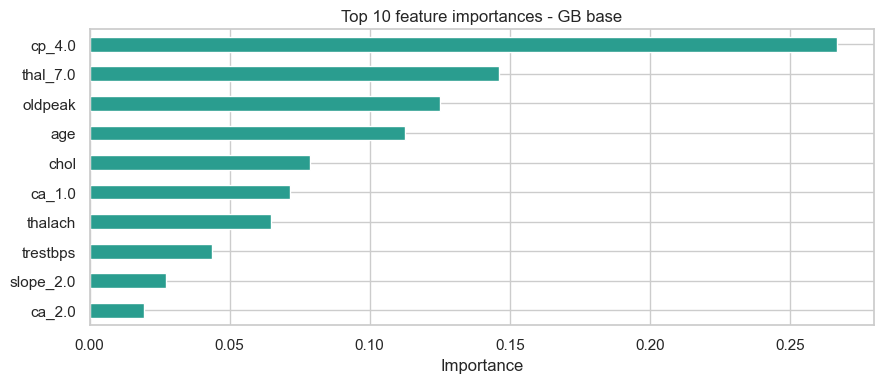

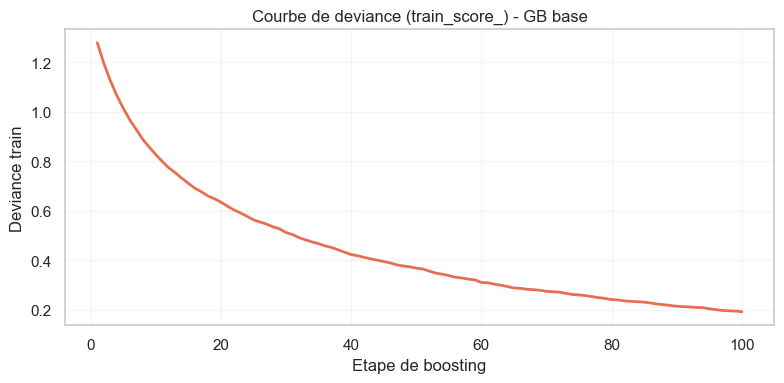

In [28]:
# 7.2 Implementation de base (n_estimators=100, learning_rate=0.1)
gb_base = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE,
)
gb_base.fit(X_train_b, y_train_b)

# Importances des variables
gb_importances = (
    pd.Series(gb_base.feature_importances_, index=X_train_b.columns)
    .sort_values(ascending=False)
)
display(gb_importances.head(12).rename("importance").round(4).to_frame())

plt.figure(figsize=(9, 4))
gb_importances.head(10).sort_values().plot(kind="barh", color="#2A9D8F")
plt.title("Top 10 feature importances - GB base")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Courbe de deviance (obligatoire): train_score_
plt.figure(figsize=(8, 4))
plt.plot(
    np.arange(1, len(gb_base.train_score_) + 1),
    gb_base.train_score_,
    color="#E76F51",
    lw=2,
)
plt.title("Courbe de deviance (train_score_) - GB base")
plt.xlabel("Etape de boosting")
plt.ylabel("Deviance train")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

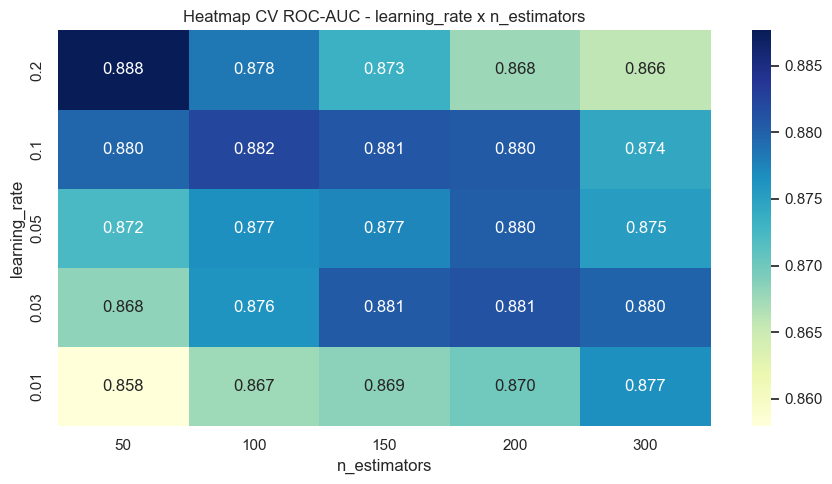

Meilleure combinaison globale: learning_rate=0.2, n_estimators=50, CV ROC-AUC=0.888
Meilleure combinaison respectant la regle (learning_rate faible + n_estimators eleve): learning_rate=0.03, n_estimators=200, CV ROC-AUC=0.881
Regle pedagogique: a performance proche, preferer learning_rate plus faible + n_estimators plus eleve pour une optimisation plus progressive.


In [29]:
# 7.3 Impact learning_rate x n_estimators (heatmap obligatoire)
learning_rate_grid = [0.01, 0.03, 0.05, 0.1, 0.2]
n_estimators_grid = [50, 100, 150, 200, 300]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
heatmap_rows = []

for lr in learning_rate_grid:
    for n_est in n_estimators_grid:
        model = GradientBoostingClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            max_depth=3,
            random_state=RANDOM_STATE,
        )
        auc_scores = cross_val_score(
            model,
            X_train_b,
            y_train_b,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1,
        )
        heatmap_rows.append(
            {
                "learning_rate": lr,
                "n_estimators": n_est,
                "cv_auc": float(np.mean(auc_scores)),
            }
        )

heatmap_df = pd.DataFrame(heatmap_rows)
heatmap_pivot = heatmap_df.pivot(
    index="learning_rate",
    columns="n_estimators",
    values="cv_auc",
).sort_index(ascending=False)

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Heatmap CV ROC-AUC - learning_rate x n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("learning_rate")
plt.tight_layout()
plt.show()

best_combo = heatmap_df.sort_values("cv_auc", ascending=False).iloc[0]
rule_subset = heatmap_df[
    (heatmap_df["learning_rate"] <= 0.05) & (heatmap_df["n_estimators"] >= 200)
].sort_values("cv_auc", ascending=False)

print(
    "Meilleure combinaison globale:",
    f"learning_rate={best_combo['learning_rate']},",
    f"n_estimators={int(best_combo['n_estimators'])},",
    f"CV ROC-AUC={best_combo['cv_auc']:.3f}",
)
if not rule_subset.empty:
    rule_best = rule_subset.iloc[0]
    print(
        "Meilleure combinaison respectant la regle (learning_rate faible + n_estimators eleve):",
        f"learning_rate={rule_best['learning_rate']},",
        f"n_estimators={int(rule_best['n_estimators'])},",
        f"CV ROC-AUC={rule_best['cv_auc']:.3f}",
    )
print(
    "Regle pedagogique: a performance proche, preferer learning_rate plus faible +"
    " n_estimators plus eleve pour une optimisation plus progressive."
)

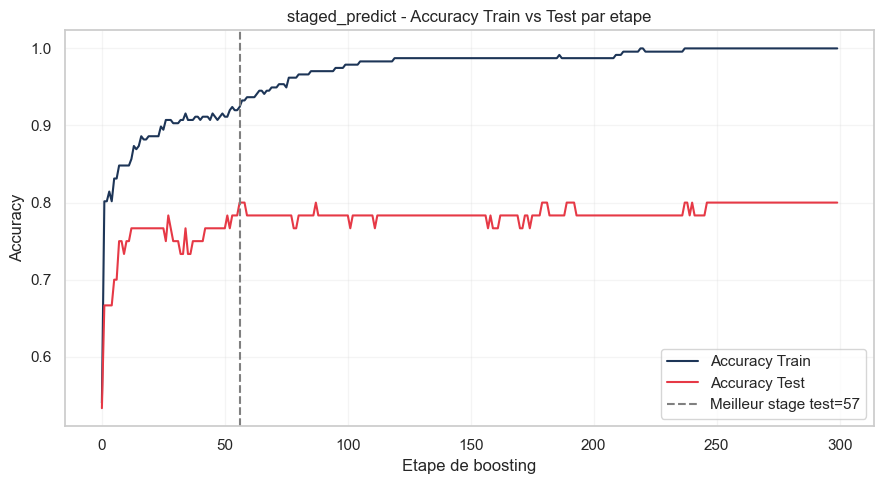

Meilleure accuracy test: 0.800 au stage 57
Accuracy train au meme stage: 0.924


In [30]:
# 7.4 staged_predict: detection du surapprentissage (Accuracy Train vs Test)
gb_stage = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE,
)
gb_stage.fit(X_train_b, y_train_b)

train_acc_stages = []
test_acc_stages = []

for y_train_pred_stage, y_test_pred_stage in zip(
    gb_stage.staged_predict(X_train_b),
    gb_stage.staged_predict(X_test_b),
):
    train_acc_stages.append(accuracy_score(y_train_b, y_train_pred_stage))
    test_acc_stages.append(accuracy_score(y_test_b, y_test_pred_stage))

best_stage = int(np.argmax(test_acc_stages) + 1)

plt.figure(figsize=(9, 5))
plt.plot(train_acc_stages, label="Accuracy Train", color="#1D3557")
plt.plot(test_acc_stages, label="Accuracy Test", color="#E63946")
plt.axvline(best_stage - 1, ls="--", color="gray", label=f"Meilleur stage test={best_stage}")
plt.title("staged_predict - Accuracy Train vs Test par etape")
plt.xlabel("Etape de boosting")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Meilleure accuracy test: {max(test_acc_stages):.3f} au stage {best_stage}")
print(f"Accuracy train au meme stage: {train_acc_stages[best_stage - 1]:.3f}")

,subsample,train_accuracy,test_accuracy,train_auc,test_auc,overfit_gap_auc,overfit_gap_acc
0,0.50,1.0,0.85,1.0,0.916,0.084,0.15
1,0.75,1.0,0.85,1.0,0.906,0.094,0.15
2,1.00,1.0,0.80,1.0,0.886,0.114,0.20


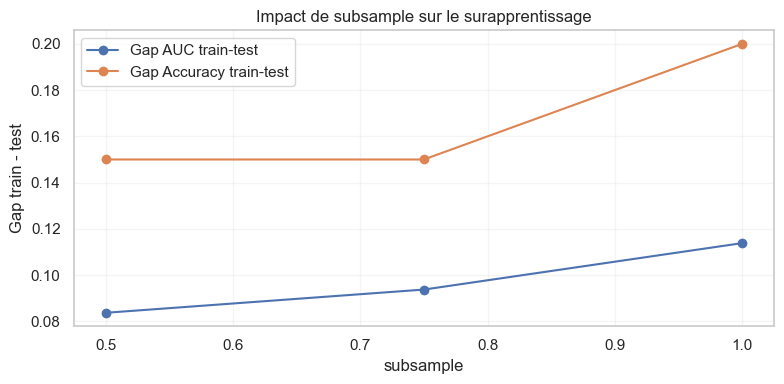

In [31]:
# 7.5 Stochastic Gradient Boosting: impact de subsample sur le surapprentissage
subsample_values = [0.5, 0.75, 1.0]
stoch_rows = []

for s in subsample_values:
    model = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=s,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_b, y_train_b)

    y_train_prob = model.predict_proba(X_train_b)[:, 1]
    y_test_prob = model.predict_proba(X_test_b)[:, 1]
    y_train_pred = model.predict(X_train_b)
    y_test_pred = model.predict(X_test_b)

    stoch_rows.append(
        {
            "subsample": s,
            "train_accuracy": accuracy_score(y_train_b, y_train_pred),
            "test_accuracy": accuracy_score(y_test_b, y_test_pred),
            "train_auc": roc_auc_score(y_train_b, y_train_prob),
            "test_auc": roc_auc_score(y_test_b, y_test_prob),
        }
    )

stoch_df = pd.DataFrame(stoch_rows)
stoch_df["overfit_gap_auc"] = stoch_df["train_auc"] - stoch_df["test_auc"]
stoch_df["overfit_gap_acc"] = stoch_df["train_accuracy"] - stoch_df["test_accuracy"]
display(stoch_df.round(3))

plt.figure(figsize=(8, 4))
plt.plot(stoch_df["subsample"], stoch_df["overfit_gap_auc"], marker="o", label="Gap AUC train-test")
plt.plot(stoch_df["subsample"], stoch_df["overfit_gap_acc"], marker="o", label="Gap Accuracy train-test")
plt.title("Impact de subsample sur le surapprentissage")
plt.xlabel("subsample")
plt.ylabel("Gap train - test")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7.6 Analyse redigee: Boosting vs Bagging (puissance, contexte, cout)

1. Le boosting corrige les erreurs residuelles de maniere sequentielle et peut atteindre une forte performance predictive.
2. Le bagging (ex: Random Forest) reduit surtout la variance via l'agregation de modeles entraines en parallele.
3. Sur petit dataset, le boosting peut surapprendre plus vite si `learning_rate` est trop eleve ou si le nombre d'arbres est mal regle.
4. Le bagging est souvent plus stable face au bruit et aux fluctuations d'echantillonnage.
5. En depistage clinique, la stabilite et la robustesse operationnelle sont importantes autant que le score global.
6. Le cout de calcul du boosting est sequentiel, donc moins facilement parallellisable en tuning massif.
7. Le bagging est plus parallellisable et souvent plus simple a industrialiser.
8. Le boosting reste pertinent si l'objectif principal est la performance maximale et que le controle du surapprentissage est bien gere.
9. Le bagging est pertinent si l'on privilegie la robustesse, la reproductibilite et une maintenance plus simple.
10. Le choix final doit combiner metriques, profil d'erreurs (notamment faux negatifs) et contraintes de cout/temps.

In [32]:
# 7.7 Tableau de comparaison final (Modeles du cours vs notre modele)
bagging_model = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

gb_final_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.75,
    random_state=RANDOM_STATE,
)

bagging_model.fit(X_train_b, y_train_b)
gb_final_model.fit(X_train_b, y_train_b)

def metric_pack(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    return {
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision (macro)": precision_score(y_eval, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_eval, y_pred, average="macro", zero_division=0),
        "F1-Score (macro)": f1_score(y_eval, y_pred, average="macro", zero_division=0),
        "AUC-ROC": roc_auc_score(y_eval, y_prob),
    }

bag_metrics = metric_pack(bagging_model, X_test_b, y_test_b)
gb_metrics = metric_pack(gb_final_model, X_test_b, y_test_b)

comparison_table = pd.DataFrame(
    {
        "Modeles du cours (Bagging - Random Forest)": bag_metrics,
        "notre modele (Gradient Boosting)": gb_metrics,
    }
).round(3)

display(comparison_table)

print("Lecture rapide:")
print("- Si la colonne 'notre modele' domine en AUC-ROC/Recall, le boosting est plus puissant sur ce dataset.")
print("- Si les ecarts sont faibles, le bagging peut etre prefere pour sa robustesse et son cout d'exploitation.")

,Modeles du cours (Bagging - Random Forest),notre modele (Gradient Boosting)
Accuracy,0.833,0.850
Precision (macro),0.835,0.854
Recall (macro),0.830,0.846
F1-Score (macro),0.832,0.848
AUC-ROC,0.916,0.906


Lecture rapide:
- Si la colonne 'notre modele' domine en AUC-ROC/Recall, le boosting est plus puissant sur ce dataset.
- Si les ecarts sont faibles, le bagging peut etre prefere pour sa robustesse et son cout d'exploitation.
